# House Tweets — Sentiment & Emotion Analysis

Single-pass pipeline: load → preprocess → score sentiment → score emotions → aggregate → visualize.

**Steps**
1. Imports & config
2. Load & preprocess
3. Sentiment scoring (RoBERTa)
4. Emotion scoring (Hartmann)
5. Save enriched tweets
6. User-level aggregation
7. Visualizations

---
## 0 · Imports & config

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import pipeline
from tqdm import tqdm

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 100)

# ── Paths ──────────────────────────────────────────────────────────────────
HOUSE_TWEETS_CSV  = "house_tweets.csv"
SAMPLE_HOUSE_CSV  = "sample_house.csv"
ENRICHED_CSV      = "house_tweets_enriched.csv"
USER_SUMMARY_CSV  = "user_sentiment_summary.csv"

# ── Model config ───────────────────────────────────────────────────────────
SENTIMENT_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
EMOTION_MODEL   = "j-hartmann/emotion-english-distilroberta-base"
BATCH_SIZE      = 32

# ── Visualization config ───────────────────────────────────────────────────
TIME_FREQ     = "M"   # "M" = monthly, "Q" = quarterly
MISSING_COLOR = "lightgrey"

QUARTILE_ORDER = ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]

---
## 1 · Load & preprocess

In [7]:
tweets = pd.read_csv(HOUSE_TWEETS_CSV)
sample = pd.read_csv(SAMPLE_HOUSE_CSV)

print(f"Tweets loaded : {len(tweets):,}")
print(f"House members : {len(sample)}")
print(f"Columns       : {list(tweets.columns)}")
tweets.head(3)

Tweets loaded : 76,058
House members : 68
Columns       : ['Tweet_count', 'Username', 'Text', 'Created At', 'Retweets', 'Likes', 'Tweet_ID']


,Tweet_count,Username,Text,Created At,Retweets,Likes,Tweet_ID
0,RepRichardNeal,Rep. Richard Neal,"From my family and staff members to you, happy Thanksgiv...",Thu Nov 28 21:26:10 +0000 2024,0,13,1.862247e+18
1,RepRichardNeal,Rep. Richard Neal,"Tomorrow morning, tune in to watch Massachusetts' own @U...",Wed Nov 27 16:38:29 +0000 2024,0,11,1.861812e+18
2,RepRichardNeal,Rep. Richard Neal,"In western Mass, we are making great strides to improve ...",Thu Nov 21 15:47:53 +0000 2024,1,5,1.859625e+18


In [8]:
# Parse dates
tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce")
tweets = tweets.dropna(subset=["Text", "Created At"]).copy()

# Normalize the handle column (Tweet_count = screen name in your data)
tweets["handle"] = tweets["Tweet_count"].astype(str).str.strip()

# Preprocess text for models: replace @mentions and URLs
def preprocess(text):
    tokens = []
    for t in str(text).split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)

tweets["clean_text"] = tweets["Text"].apply(preprocess)

print(f"Rows after cleaning: {len(tweets):,}")
tweets[["handle", "Text", "clean_text", "Created At"]].head(3)

/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_46920/2537263725.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce")


Rows after cleaning: 76,058


,handle,Text,clean_text,Created At
0,RepRichardNeal,"From my family and staff members to you, happy Thanksgiv...","From my family and staff members to you, happy Thanksgiv...",2024-11-28 21:26:10+00:00
1,RepRichardNeal,"Tomorrow morning, tune in to watch Massachusetts' own @U...","Tomorrow morning, tune in to watch Massachusetts' own @u...",2024-11-27 16:38:29+00:00
2,RepRichardNeal,"In western Mass, we are making great strides to improve ...","In western Mass, we are making great strides to improve ...",2024-11-21 15:47:53+00:00


In [9]:
# Build handle → quartile + party mapping from sample_house
sample["handle_lower"] = sample["twitter"].str.lower().str.strip()
tweets["handle_lower"] = tweets["handle"].str.lower().str.strip()

meta_cols = ["handle_lower", "official_full", "quartile", "party_code", "state", "pct_small_donors"]
handle_meta = sample[meta_cols].drop_duplicates("handle_lower")

tweets = tweets.merge(handle_meta, on="handle_lower", how="left")

print("Quartile coverage:")
print(tweets["quartile"].value_counts())
unmatched = tweets['quartile'].isna().sum()
print(f"Unmatched handles: {tweets['quartile'].isna().sum():,}")

Quartile coverage:
quartile
Q4 (highest)    25990
Q3              17925
Q2              17386
Q1 (lowest)     14757
Name: count, dtype: int64
Unmatched handles: 0


---
## 2 · Sentiment scoring

Runs  on every tweet.
Outputs  (Negative / Neutral / Positive), , and a continuous
 in [−1, +1].

In [ ]:
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=SENTIMENT_MODEL,
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512,
)

def run_pipeline(pipe, texts, chunk_size=5000, desc="Scoring"):
    results = []
    for i in tqdm(range(0, len(texts), chunk_size), desc=desc):
        results.extend(pipe(texts[i:i+chunk_size], truncation=True, max_length=512))
    return results

sent_preds = run_pipeline(sentiment_pipe, tweets["clean_text"].tolist(), desc="Sentiment")

tweets["label"]      = [p["label"].lower().strip() for p in sent_preds]
tweets["confidence"] = [p["score"]                 for p in sent_preds]

def sentiment_score(label, conf):
    if label == "negative": return -conf
    if label == "positive": return  conf
    return 0.0

tweets["sentiment_score"] = [
    sentiment_score(l, c) for l, c in zip(tweets["label"], tweets["confidence"])
]

print(tweets[["label", "confidence", "sentiment_score"]].describe().round(3))
print("Label breakdown:")
print(tweets["label"].value_counts())

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Sentiment: 100%|██████████| 16/16 [1:02:08<00:00, 233.01s/it]


       confidence  sentiment_score
count   76058.000        76058.000
mean        0.806            0.222
std         0.158            0.710
min         0.341           -0.960
25%         0.679           -0.529
50%         0.852            0.000
75%         0.947            0.945
max         0.993            0.993
Label breakdown:
label
positive    37076
negative    20194
neutral     18788
Name: count, dtype: int64


---
## 3 · Emotion scoring

Runs , extracting anger, fear, and joy
scores (each in [0, 1]) per tweet.

In [ ]:
emotion_pipe = pipeline(
    "text-classification",
    model=EMOTION_MODEL,
    return_all_scores=True,
    truncation=True,
)

emo_preds = run_pipeline(emotion_pipe, tweets["clean_text"].tolist(), desc="Emotions")

def extract_score(result, target):
    for item in result:
        if item["label"].lower() == target:
            return item["score"]
    return 0.0

for emotion in ["anger", "fear", "joy", "disgust", "sadness", "surprise", "neutral"]:
    tweets[emotion] = [extract_score(r, emotion) for r in emo_preds]

print(tweets[["anger", "fear", "joy", "disgust", "sadness"]].describe().round(3))

/Users/anngo/anaconda3/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:105: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Emotions: 100%|██████████| 16/16 [26:33<00:00, 99.59s/it] 


           anger       fear        joy    disgust    sadness
count  76058.000  76058.000  76058.000  76058.000  76058.000
mean       0.117      0.205      0.300      0.042      0.072
std        0.204      0.303      0.376      0.125      0.175
min        0.000      0.000      0.000      0.000      0.001
25%        0.008      0.007      0.006      0.001      0.006
50%        0.024      0.033      0.052      0.002      0.014
75%        0.113      0.295      0.685      0.015      0.040
max        0.994      0.996      0.994      0.991      0.993


---
## 4 · Save enriched tweets

In [ ]:
tweets.to_csv(ENRICHED_CSV, index=False)
print(f"Saved → {ENRICHED_CSV}  ({len(tweets):,} rows, {len(tweets.columns)} columns)")
tweets.head(3)

Saved → house_tweets_enriched.csv  (76,058 rows, 25 columns)


,Tweet_count,Username,Text,Created At,Retweets,Likes,Tweet_ID,handle,clean_text,handle_lower,...,label,confidence,sentiment_score,anger,fear,joy,disgust,sadness,surprise,neutral
0,RepRichardNeal,Rep. Richard Neal,"From my family and staff members to you, happy Thanksgiv...",2024-11-28 21:26:10+00:00,0,13,1.862247e+18,RepRichardNeal,"From my family and staff members to you, happy Thanksgiv...",reprichardneal,...,positive,0.988786,0.988786,0.001821,0.000317,0.965662,0.000716,0.003821,0.017453,0.010210
1,RepRichardNeal,Rep. Richard Neal,"Tomorrow morning, tune in to watch Massachusetts' own @U...",2024-11-27 16:38:29+00:00,0,11,1.861812e+18,RepRichardNeal,"Tomorrow morning, tune in to watch Massachusetts' own @u...",reprichardneal,...,positive,0.695295,0.695295,0.007524,0.011979,0.638839,0.000429,0.047984,0.206454,0.086790
2,RepRichardNeal,Rep. Richard Neal,"In western Mass, we are making great strides to improve ...",2024-11-21 15:47:53+00:00,1,5,1.859625e+18,RepRichardNeal,"In western Mass, we are making great strides to improve ...",reprichardneal,...,positive,0.972556,0.972556,0.005206,0.000948,0.889421,0.003373,0.004856,0.034967,0.061229


---
## 5 · User-level aggregation

In [14]:
# ── Load pre-scored data instead of re-running models ───────────────────────
tweets = pd.read_csv("house_tweets_enriched.csv")
tweets["Created At"] = pd.to_datetime(tweets["Created At"], errors="coerce")
print(f"Loaded {len(tweets):,} rows with {len(tweets.columns)} columns")
print(tweets.columns.tolist())

Loaded 76,058 rows with 25 columns
['Tweet_count', 'Username', 'Text', 'Created At', 'Retweets', 'Likes', 'Tweet_ID', 'handle', 'clean_text', 'handle_lower', 'official_full', 'quartile', 'party_code', 'state', 'pct_small_donors', 'label', 'confidence', 'sentiment_score', 'anger', 'fear', 'joy', 'disgust', 'sadness', 'surprise', 'neutral']


In [15]:
user_summary = (
    tweets.groupby(["handle", "official_full", "quartile", "party_code", "pct_small_donors"])
    .agg(
        tweet_count      = ("sentiment_score", "count"),
        avg_sentiment    = ("sentiment_score", "mean"),
        sentiment_std    = ("sentiment_score", "std"),
        pct_negative     = ("sentiment_score", lambda x: (x < 0).mean()),
        pct_positive     = ("sentiment_score", lambda x: (x > 0).mean()),
        pct_extreme      = ("sentiment_score", lambda x: (abs(x) > 0.8).mean()),
        avg_anger        = ("anger",           "mean"),
        avg_fear         = ("fear",            "mean"),
        avg_joy          = ("joy",             "mean"),
        avg_disgust      = ("disgust",         "mean"),
        avg_sadness      = ("sadness",         "mean"),
    )
    .reset_index()
    .sort_values(["quartile", "avg_sentiment"])
)

user_summary.to_csv(USER_SUMMARY_CSV, index=False)
print(f"Saved → {USER_SUMMARY_CSV}  ({len(user_summary)} members)")
user_summary[["official_full", "quartile", "party_code",
              "avg_sentiment", "avg_anger", "tweet_count"]]

Saved → user_sentiment_summary.csv  (64 members)


,official_full,quartile,party_code,avg_sentiment,avg_anger,tweet_count
31,Lloyd Doggett,Q1 (lowest),D,-0.038218,0.159191,1894
55,William R. Timmons IV,Q1 (lowest),R,-0.011014,0.171792,416
12,Jake Auchincloss,Q1 (lowest),D,0.060701,0.140375,552
6,"Frank Pallone, Jr.",Q1 (lowest),D,0.117834,0.143220,3150
9,John R. Carter,Q1 (lowest),R,0.160385,0.118254,605
45,Ron Estes,Q1 (lowest),R,0.198179,0.103008,733
30,Laurel M. Lee,Q1 (lowest),R,0.211148,0.078878,784
34,Tracey Mann,Q1 (lowest),R,0.214879,0.152387,275
24,Glenn Ivey,Q1 (lowest),D,0.304186,0.128183,525
11,Patrick T. McHenry,Q1 (lowest),R,0.381239,0.107359,482


---
## 6 · Visualizations

All heatmaps sort representatives by quartile (Q1 → Q4), then by party within quartile.
Missing periods appear in light grey.

In [ ]:
# ── Shared helpers ─────────────────────────────────────────────────────────

def quartile_sorted_order(df, handle_col="handle"):
    """Return handles sorted by quartile order then party_code."""
    meta = (
        df[[handle_col, "official_full", "quartile", "party_code"]]
        .drop_duplicates(handle_col)
        .copy()
    )
    meta["q_rank"] = pd.Categorical(meta["quartile"], categories=QUARTILE_ORDER, ordered=True)
    meta = meta.sort_values(["q_rank", "party_code", handle_col])
    return meta[handle_col].tolist(), meta["official_full"].tolist(), meta["quartile"].tolist()


def quartile_dividers(handle_order, quartile_list):
    """Return y-positions between quartile groups for hline dividers."""
    dividers = []
    for i in range(1, len(quartile_list)):
        if quartile_list[i] != quartile_list[i - 1]:
            dividers.append(i - 0.5)
    return dividers


def plot_heatmap(pivot, title, cbar_label, vmin=None, vmax=None,
                cmap_name="coolwarm", quartile_list=None, figsize=(16, 8)):
    """Generic heatmap with optional quartile divider lines."""
    data = np.ma.masked_invalid(pivot.values)

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad(color=MISSING_COLOR)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)

    # Quartile divider lines
    if quartile_list:
        for y in quartile_dividers(pivot.index.tolist(), quartile_list):
            ax.axhline(y, color="black", linewidth=1.5, linestyle="--")

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Time period", fontsize=10)
    ax.set_ylabel("Representative", fontsize=10)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label)

    plt.tight_layout()
    plt.show()


print("Helpers defined.")

Helpers defined.


/var/folders/st/yx5_mdvj4bdbm59sg4_7n26m0000gq/T/ipykernel_3800/4155909761.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tweets["period"] = tweets["Created At"].dt.to_period(TIME_FREQ)


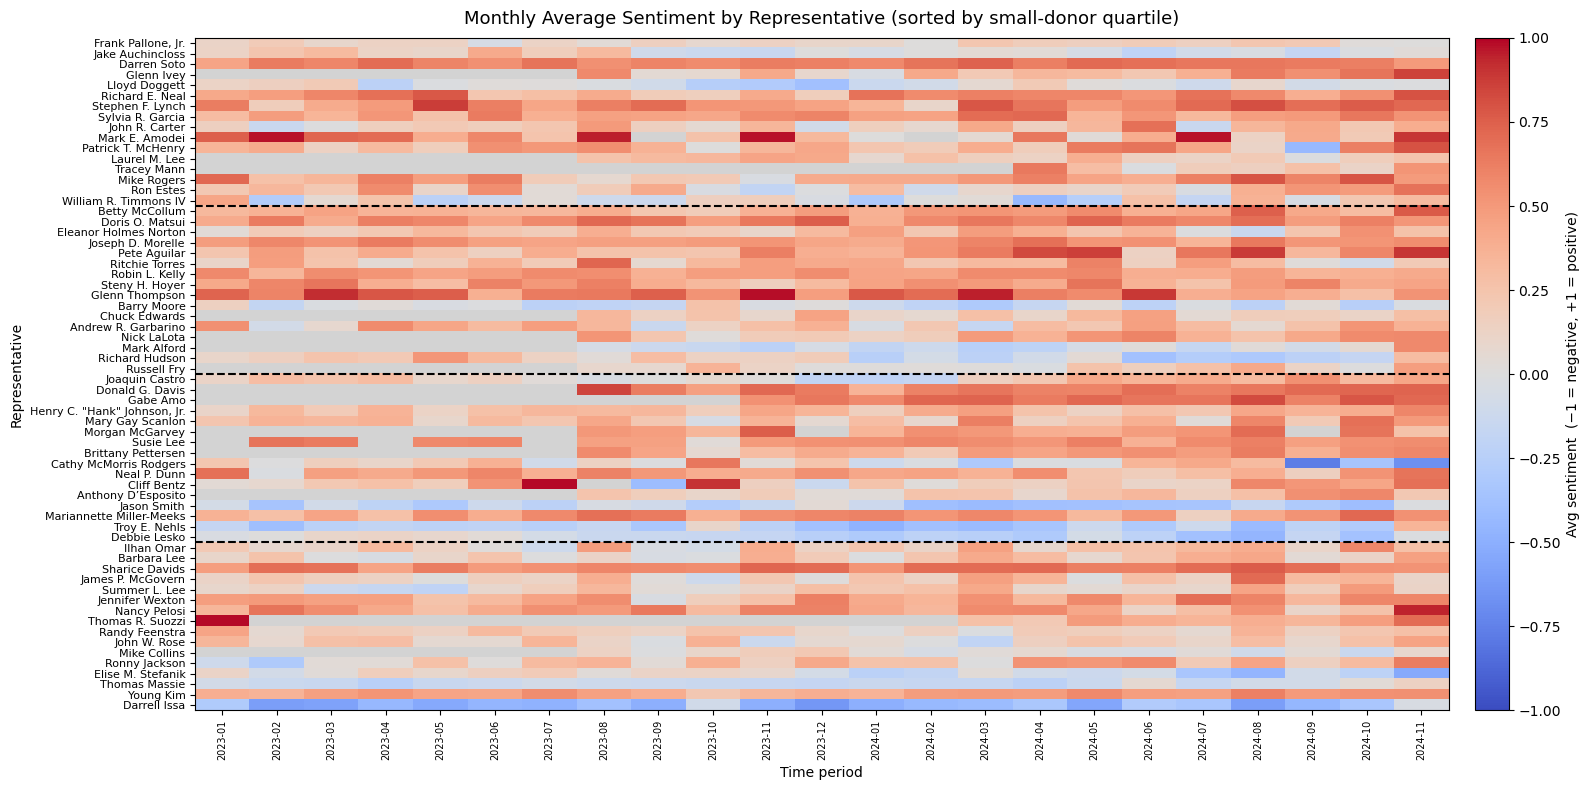

In [ ]:
# ── 6a · Sentiment heatmap ──────────────────────────────────────────────────

tweets["period"] = tweets["Created At"].dt.to_period(TIME_FREQ)
all_periods = pd.period_range(tweets["period"].min(), tweets["period"].max(), freq=TIME_FREQ)

handle_order, name_order, q_order = quartile_sorted_order(tweets)

sent_pivot = (
    tweets.groupby(["handle", "period"])["sentiment_score"]
    .mean()
    .unstack()
    .reindex(index=handle_order, columns=all_periods)
)
sent_pivot.index = name_order   # show full names on y-axis
sent_pivot.columns = sent_pivot.columns.astype(str)

freq_label = "Monthly" if TIME_FREQ == "M" else "Quarterly"
plot_heatmap(
    sent_pivot,
    title=f"{freq_label} Average Sentiment by Representative (sorted by small-donor quartile)",
    cbar_label="Avg sentiment  (−1 = negative, +1 = positive)",
    vmin=-1, vmax=1,
    cmap_name="coolwarm",
    quartile_list=q_order,
)

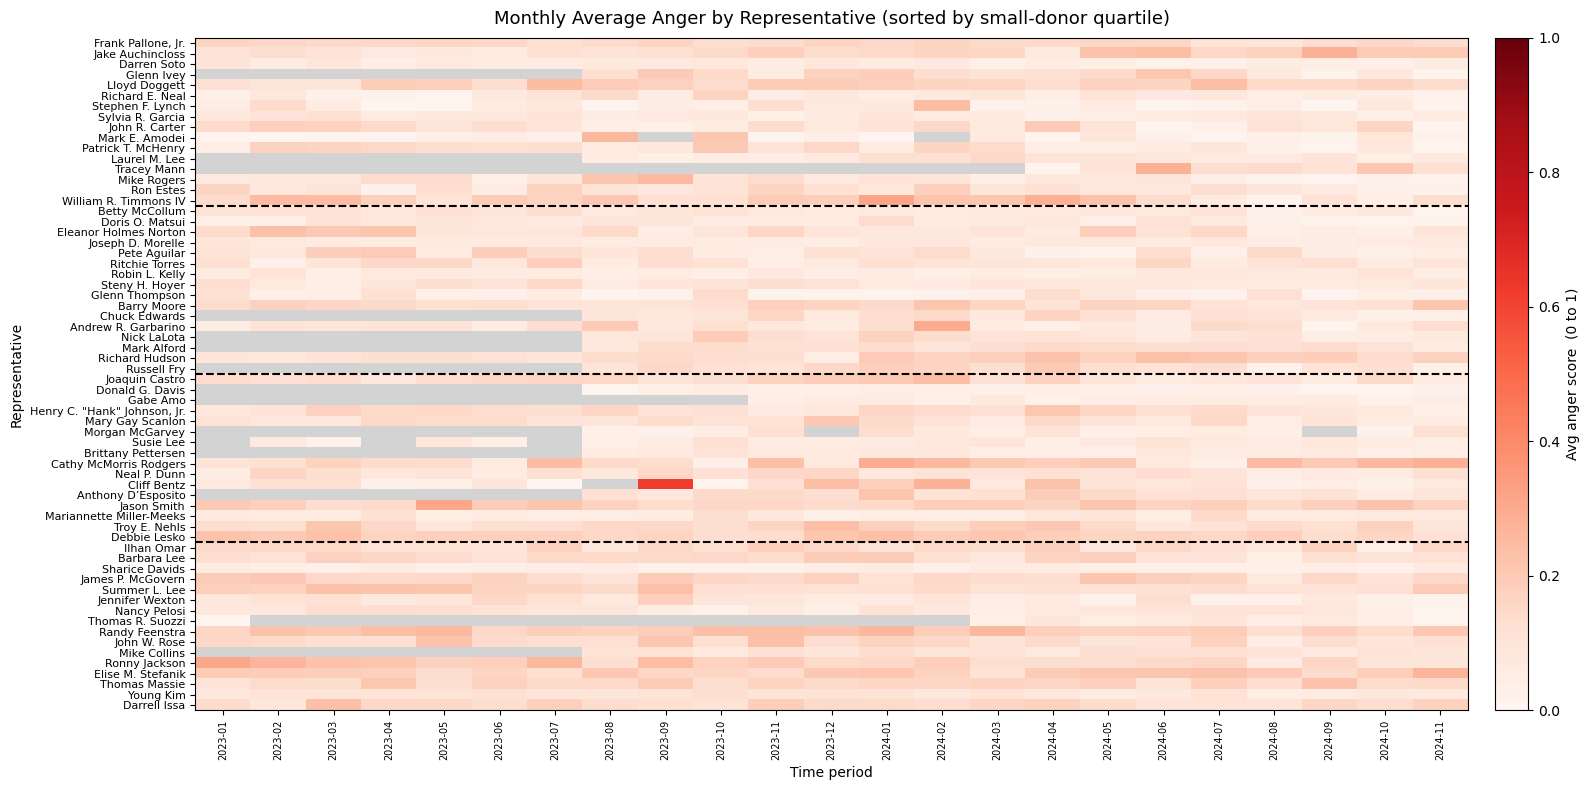

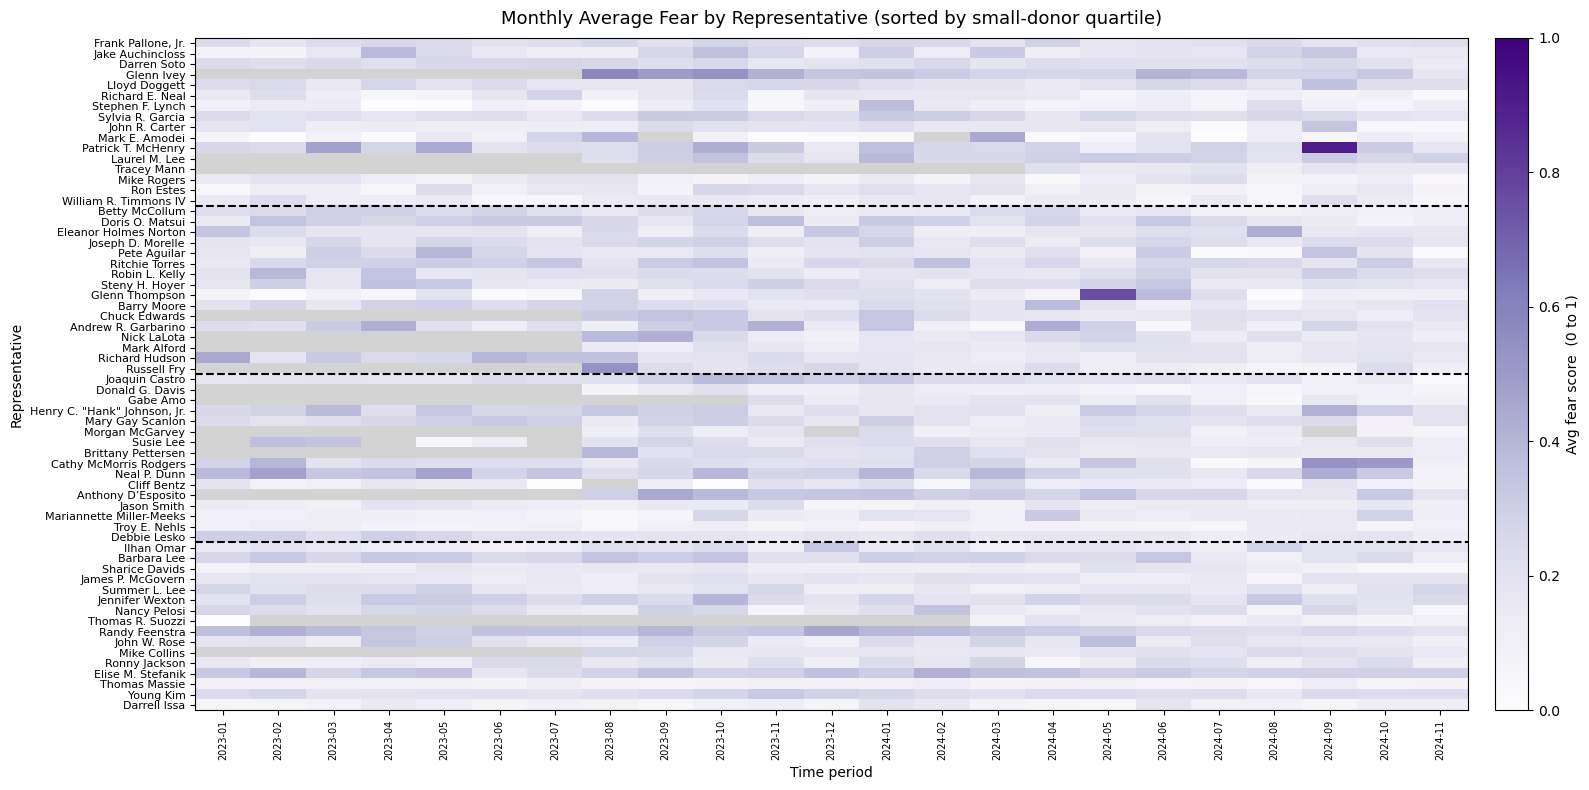

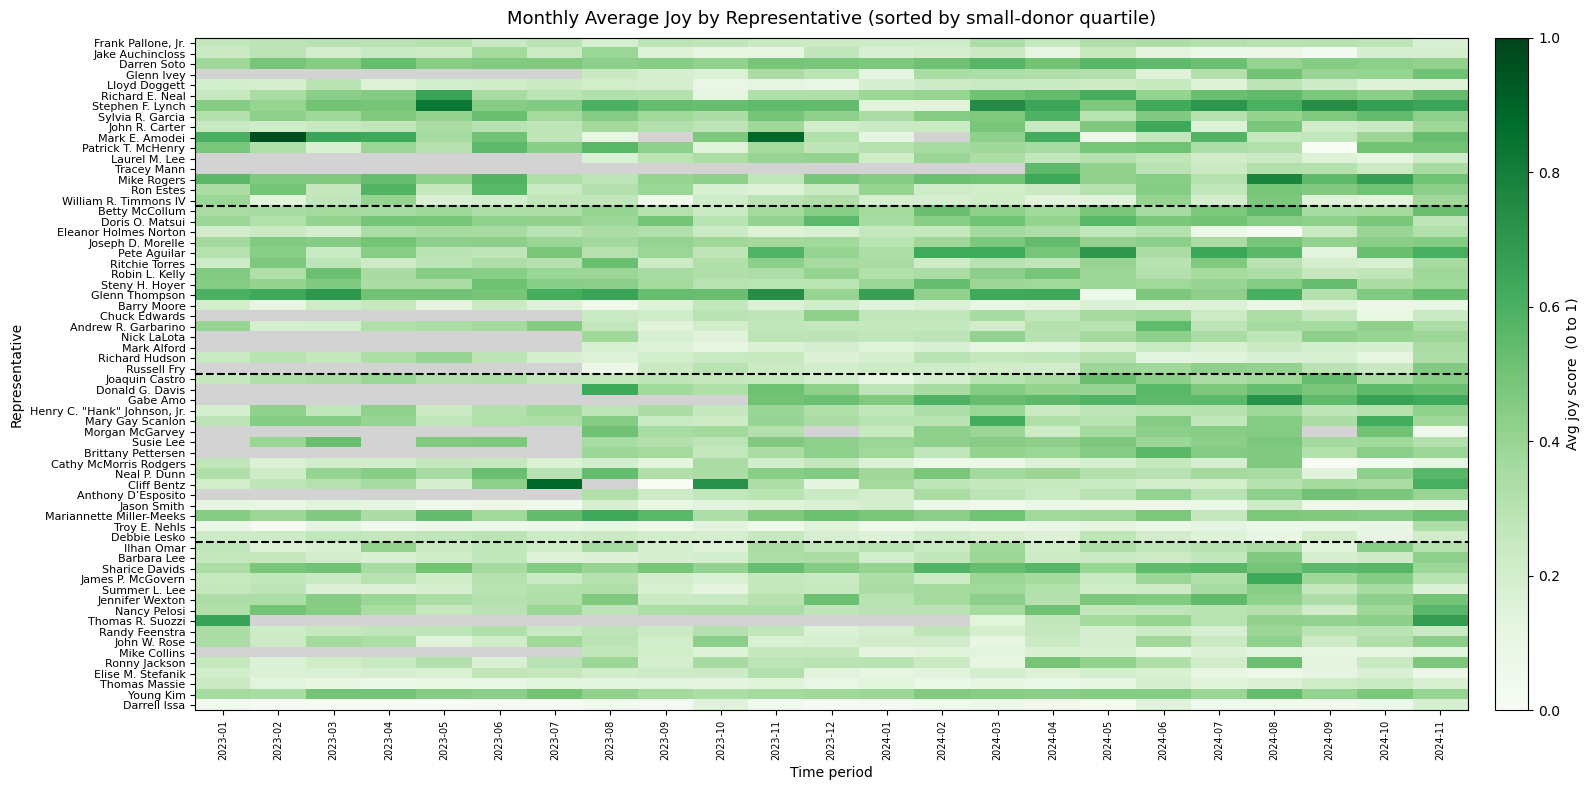

In [ ]:
# ── 6b · Emotion heatmaps (anger / fear / joy) ─────────────────────────────

for emotion, cmap in [("anger", "Reds"), ("fear", "Purples"), ("joy", "Greens")]:
    emo_pivot = (
        tweets.groupby(["handle", "period"])[emotion]
        .mean()
        .unstack()
        .reindex(index=handle_order, columns=all_periods)
    )
    emo_pivot.index = name_order
    emo_pivot.columns = emo_pivot.columns.astype(str)

    plot_heatmap(
        emo_pivot,
        title=f"{freq_label} Average {emotion.title()} by Representative (sorted by small-donor quartile)",
        cbar_label=f"Avg {emotion} score  (0 to 1)",
        vmin=0, vmax=1,
        cmap_name=cmap,
        quartile_list=q_order,
    )

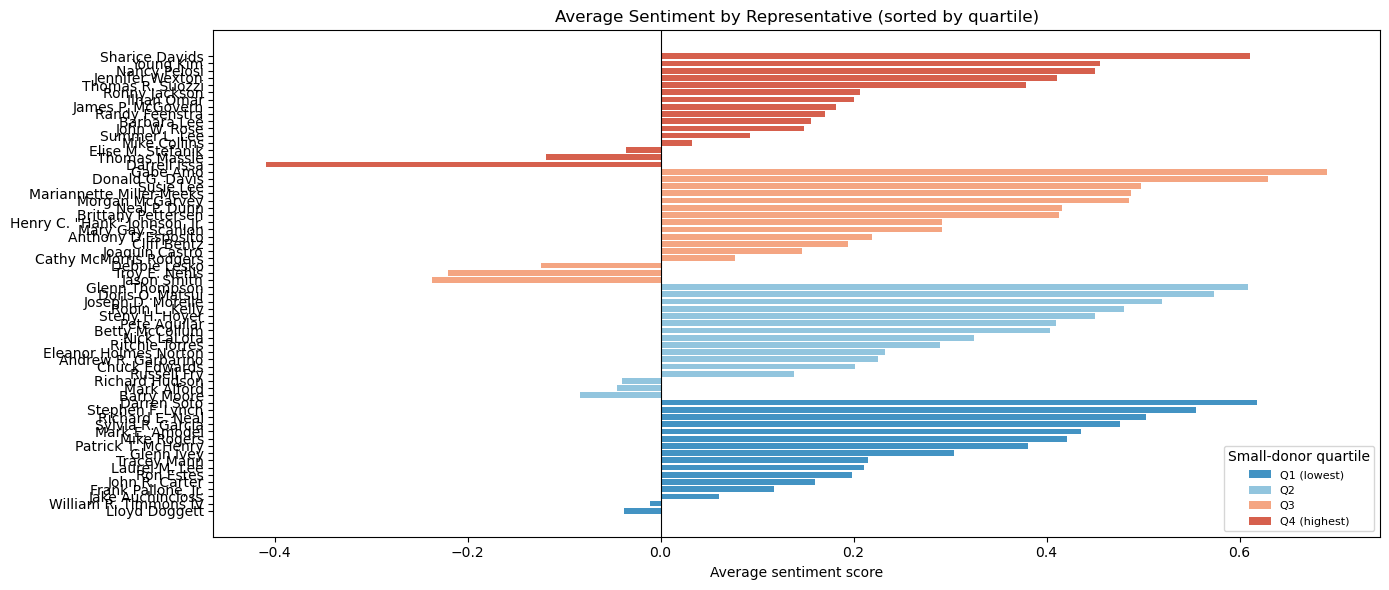

In [ ]:
# ── 6c · User summary bar chart: avg sentiment by rep, coloured by quartile ─

q_colors = {
    "Q1 (lowest)":  "#4393c3",
    "Q2":           "#92c5de",
    "Q3":           "#f4a582",
    "Q4 (highest)": "#d6604d",
}

summary_sorted = (
    user_summary.copy()
    .assign(q_rank=lambda d: pd.Categorical(
        d["quartile"], categories=QUARTILE_ORDER, ordered=True))
    .sort_values(["q_rank", "avg_sentiment"])
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    summary_sorted["official_full"],
    summary_sorted["avg_sentiment"],
    color=[q_colors.get(q, "grey") for q in summary_sorted["quartile"]],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Average sentiment score")
ax.set_title("Average Sentiment by Representative (sorted by quartile)")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=q) for q, c in q_colors.items()]
ax.legend(handles=legend_elements, title="Small-donor quartile",
          loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols("avg_sentiment ~ pct_small_donors + C(party_code)", data=user_summary).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          avg_sentiment   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     9.919
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           0.000186
Time:                        10:43:46   Log-Likelihood:                 10.111
No. Observations:                  64   AIC:                            -14.22
Df Residuals:                      61   BIC:                            -7.744
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.3962      0

In [ ]:
import numpy as np

engagement_summary["log_retweets"] = np.log1p(engagement_summary["avg_retweets"])
engagement_summary["log_likes"]    = np.log1p(engagement_summary["avg_likes"])

model_rt_log = smf.ols("log_retweets ~ pct_small_donors + C(party_code)", data=engagement_summary).fit()
print("=== Log Retweets ===")
print(model_rt_log.summary())

model_lk_log = smf.ols("log_likes ~ pct_small_donors + C(party_code)", data=engagement_summary).fit()
print("=== Log Likes ===")
print(model_lk_log.summary())

=== Retweets ===
                            OLS Regression Results                            
Dep. Variable:           avg_retweets   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     6.112
Date:                Wed, 01 Apr 2026   Prob (F-statistic):            0.00381
Time:                        10:15:10   Log-Likelihood:                -402.27
No. Observations:                  64   AIC:                             810.5
Df Residuals:                      61   BIC:                             817.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept          